In [138]:
%pip install pyLDAvis gensim nltk praw

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import re
import gensim   
import nltk
import praw
import time
import pandas as pd
import numpy as np
import seaborn as sns
import pyLDAvis
from wordcloud import WordCloud
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import gensim.corpora as corpora
from pprint import pprint
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation

In [ ]:
# download NLTK data files
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')

wn = nltk.WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Set up the Reddit API client
reddit = praw.Reddit(client_id='jNDebfJyUZYOLz6TA9BFiw', client_secret='8kNu2dL5bDQLmfCYXH4DmIa4wUTFzQ', user_agent='developers')

# Define the keywords and subreddits to search in
keywords = ['cryptocurrency', 'crypto', 'blockchain', 'bitcoin', 'ethereum', 'business', 'finance', 'trading', 'wallet', 'digital', 'economy', 'stocks', 'currency'] # Specify Keywords here
subreddits = ['CryptoCurrency', 'Bitcoin', 'Ethereum', 'Altcoin', 'NFT', 'Memecoins', 'Finance', 'Trading', 'Investment'] # Specify the subreddits

# Define the number of posts to retrieve in total
num_posts = 1500

# Define a list to store the extracted data
data = []

# Loop through each subreddit
for subreddit in subreddits:
    try:
        # Use PRAW's search method with a limit
        search_results = reddit.subreddit(subreddit).search(f"{' OR '.join(keywords)}", limit=num_posts)
        for result in search_results:
            # Check if the post has a non-empty selftext field
            if result.selftext:
                # Extract the relevant data from each post
                post_title = result.title
                post_text = result.selftext
                post_author = result.author.name if result.author else "Unknown"
                post_created_utc = result.created_utc
                # Store the data in the list
                data.append({'title': post_title, 'text': post_text, 'author': post_author, 'created_utc': post_created_utc})
                print(f"Retrieved post {len(data)} from subreddit {subreddit}: {post_title}")
            # Stop if the desired number of posts is reached
            if len(data) >= num_posts:
                break
        # Delay to avoid hitting rate limits
        time.sleep(4)
    except Exception as e:
       print(f"Error fetching posts from subreddit {subreddit}: {e}") 

Retrieved post 1 from subreddit CryptoCurrency: A list of 43 countrys and their cryptocurrency regulations
Retrieved post 2 from subreddit CryptoCurrency: Messari's "Crypto Theses for 2024" (with summarized recap)
Retrieved post 3 from subreddit CryptoCurrency: Will Bitcoin replace the US Dollar in our lifetime? - A deep dive into the past, present, and future of Bitcoin - And why it matters
Retrieved post 4 from subreddit CryptoCurrency: The definitive list of non-crypto crypto investments.
Retrieved post 5 from subreddit CryptoCurrency: How To Get Rich With Bitcoin Even If You Have No Clue About Technology
Retrieved post 6 from subreddit CryptoCurrency: How To Get Rich With Bitcoin Even If You Have No Clue About Technology
Retrieved post 7 from subreddit CryptoCurrency: How To Get Rich With Bitcoin Even If You Have No Clue About Technology
Retrieved post 8 from subreddit CryptoCurrency: Cryptocurrency Weekly Recap
Retrieved post 9 from subreddit CryptoCurrency: My growing collection 

In [ ]:
# Convert the list of dictionaries to a pandas DataFrame
reddit_post_df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
reddit_post_df.to_csv('reddit_posts.csv', index=False)

In [278]:
# Load the CSV file
posts_df = pd.read_csv("reddit_posts.csv")

#### Exploratory Analysis

In [279]:
posts_df.head()

,title,text,author,created_utc
0,A list of 43 countrys and their cryptocurrency...,It took a bit more time than expected but i co...,steavus,1.616069e+09
1,"Messari's ""Crypto Theses for 2024"" (with summa...","If you don't know who they are, Messari is a p...",jawni,1.704224e+09
2,Will Bitcoin replace the US Dollar in our life...,The history and growth of Bitcoin in the last ...,nobjos,1.637755e+09
3,The definitive list of non-crypto crypto inves...,"With the influx of crypto users, I decided to ...",JazzyJayKarr,1.615045e+09
4,How To Get Rich With Bitcoin Even If You Have ...,**The surprising** **wealth-building secret*...,Sweet-Count2557,1.668180e+09


In [280]:
posts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        1197 non-null   object 
 1   text         1197 non-null   object 
 2   author       1197 non-null   object 
 3   created_utc  1197 non-null   float64
dtypes: float64(1), object(3)
memory usage: 37.5+ KB


In [179]:
# Drop duplicate rows
posts_df = posts_df.drop_duplicates()

# Drop rows with missing values
posts_df = posts_df.dropna()

# Group by 'title' to ensure unique titles
posts_df = posts_df.groupby('title').first().reset_index()
posts_df = posts_df.groupby('text').first().reset_index()

# Reset the index
posts_df = posts_df.reset_index(drop=True)

# Verify the balance
posts_df.describe(include='all')

,text,title,author,created_utc
count,1170,1170,1170,1.170000e+03
unique,1170,1170,948,NaN
top,🚀 Mission-Driven: Protecting the Crypto Space\...,Catbat Will Be The Next Billion-Dollar Crypto-...,DAHUDMJ,NaN
freq,1,1,18,NaN
mean,NaN,NaN,NaN,1.693557e+09
std,NaN,NaN,NaN,6.205148e+07
min,NaN,NaN,NaN,1.271341e+09
25%,NaN,NaN,NaN,1.640137e+09
50%,NaN,NaN,NaN,1.725250e+09
75%,NaN,NaN,NaN,1.738240e+09


In [180]:
posts_df = posts_df.drop(columns=['created_utc', 'author'])

count     1197.000000
mean      1891.009190
std       3662.664001
min          2.000000
25%        317.000000
50%        860.000000
75%       1894.000000
max      39866.000000
Name: text, dtype: float64


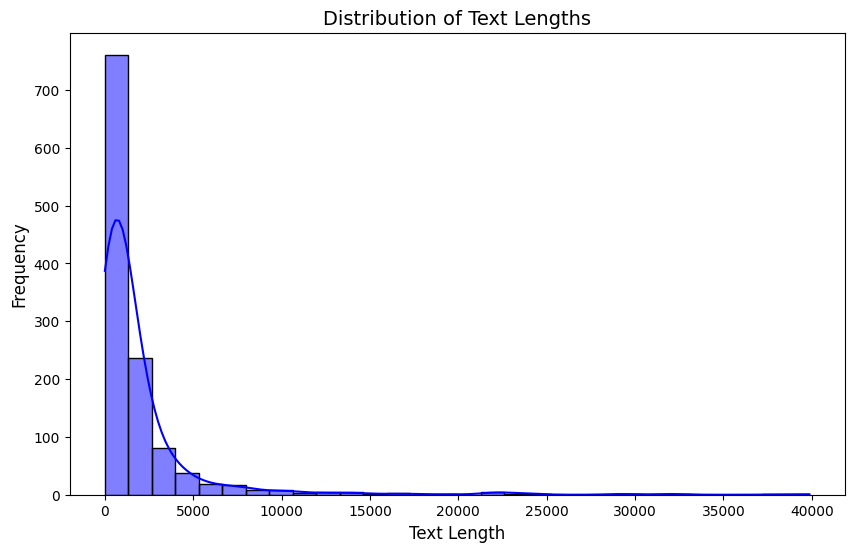

In [287]:
# Calculate the length of each post's text
text_length = posts_df['text'].apply(len)

# Display basic statistics about text lengths
print(text_length.describe())

# Plot the distribution of text lengths
plt.figure(figsize=(10, 6))
sns.histplot(text_length, bins=30,kde=True, color='blue')
plt.title('Distribution of Text Lengths', fontsize=14)
plt.xlabel('Text Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [ ]:
# Remove punctuation
posts_df['cleaned_text'] = posts_df['text'].map(lambda x: re.sub(r'[,\.!?]', '', x))

# Convert the titles to lowercase
posts_df['cleaned_text'] = posts_df['cleaned_text'].map(lambda x: x.lower())

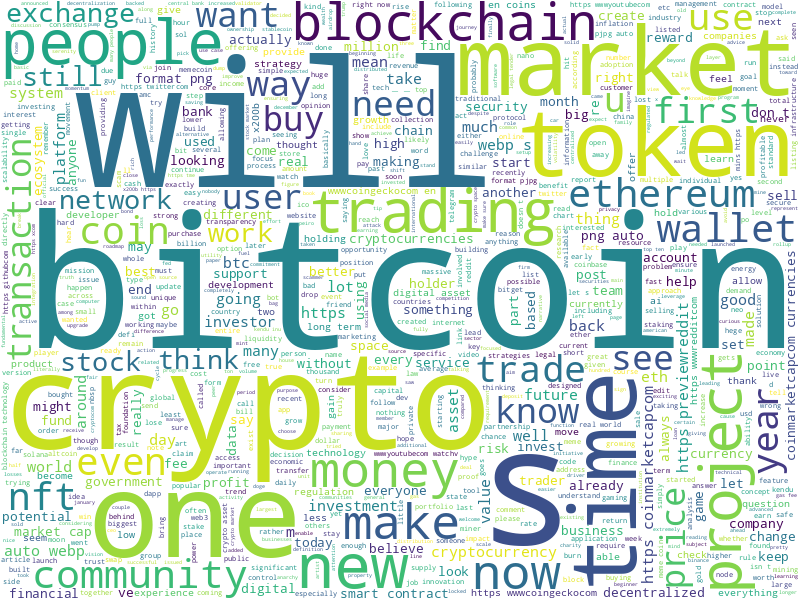

In [276]:
# Join the different processed titles together.
long_string = ','.join(list(posts_df['cleaned_text'].values))

# Create a WordCloud object
wordcloud = WordCloud(
    background_color="white", 
    max_words=2000, 
    contour_width=3, 
    width=800, 
    height=600, 
    contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

In [194]:
# prepare text for LDA Analysis
stop_words = stopwords.words('english')

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc))
             if word not in stop_words] for doc in texts]


data = posts_df.cleaned_text.values.tolist()
data_words = list(sent_to_words(data))

# remove stop words
data_words = remove_stopwords(data_words)

print(data_words[:1][0][:30])

['overview', 'icon', 'project', 'icx', 'cutting', 'edge', 'blockchain', 'platform', 'dedicated', 'hyperconnecting', 'world', 'establishing', 'decentralized', 'network', 'icon', 'facilitates', 'seamless', 'interactions', 'independent', 'blockchains', 'across', 'various', 'sectors', 'including', 'finance', 'security', 'insurance', 'healthcare', 'education', 'commerce']


In [195]:
# create dictionary
id2word = corpora.Dictionary(data_words)

# create corpus
texts = data_words

# term document frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 2), (3, 1), (4, 1), (5, 2), (6, 1), (7, 1), (8, 3), (9, 1), (10, 1), (11, 1), (12, 1), (13, 3), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 4), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1)]


In [183]:
# prepare to remove stopwords
stopwords = nltk.corpus.stopwords.words('english')
stopwords.extend(['mr', 'said','imf','using','say','will'])
print(f'There are {len(stopwords)} default stopwords. They are {stopwords}')

There are 204 default stopwords. They are ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own',

In [184]:
# Remove stopwords
posts_df['text_without_stopwords'] = posts_df['text'].apply(lambda x: ' '.join([w for w in x.split() if w.lower() not in stopwords]))

# perform lemmatization
posts_df['text_lemmatized'] = posts_df['text_without_stopwords'].apply(lambda x: ' '.join([wn.lemmatize(w) for w in x.split() if w not in stopwords]))

# take a look at the data
posts_df.head()

,text,title,cleaned_text,text_without_stopwords,text_lemmatized
0,\n\n\nOverview: The ICON Project (ICX) is a cu...,The ICON Project (ICX): Revolutionizing Blockc...,\n\n\noverview: the icon project (icx) is a cu...,Overview: ICON Project (ICX) cutting-edge bloc...,Overview: ICON Project (ICX) cutting-edge bloc...
1,\n\n\nSender AI Network is taking blockchain t...,Sender Ai aims to improve the blockchain,\n\n\nsender ai network is taking blockchain t...,Sender AI Network taking blockchain next level...,Sender AI Network taking blockchain next level...
2,\n\n1. Which is the stable currency to hold as...,🌟which currency to hold in Assets ?🚀,\n\n1 which is the stable currency to hold as ...,"1. stable currency hold asset long-term , cons...","1. stable currency hold asset long-term , cons..."
3,\n\nEdit 8: Important **NEW TOOL**---> [Coinba...,This can't be put off or delayed. They are abo...,\n\nedit 8: important **new tool**---> [coinba...,Edit 8: Important **NEW TOOL**---> [Coinbase c...,Edit 8: Important **NEW TOOL**---> [Coinbase c...
4,"\n\nFirst things first, trading for a living i...",80% Yearly Returns Trading Big Caps - My Basic...,\n\nfirst things first trading for a living is...,"First things first, trading living going take ...","First thing first, trading living going take t..."


##### parameters selection

In [ ]:
# function to plot the top words for each topic
def plot_top_words(model, feature_names, n_top_words, title):
    n_topics = len(model.components_)
    n_cols = min(5, n_topics)  
    n_rows = (n_topics + n_cols - 1) // n_cols  

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5), sharex=True)
    axes = axes.flatten() if n_topics > 1 else [axes] 

    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.8)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 20})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)
        for spine in "top right left".split():
            ax.spines[spine].set_visible(False)

    # Hide unused subplots
    for i in range(topic_idx + 1, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(title, fontsize=25)
    plt.subplots_adjust(top=0.85, bottom=0.1, wspace=0.4, hspace=0.6)
    plt.show()

In [ ]:
# function to generate wordclouds
def generate_wordclouds_with_corpus(model, feature_names, model_name):
    for topic_idx, topic in enumerate(model.components_):
        # Extract the top words and their weights for the topic
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        top_weights = topic[top_features_ind]
        
        # Create a dictionary for the top words
        word_weights = dict(zip(top_features, top_weights))
        
        # Add other words from the corpus with smaller weights
        for word in feature_names:
            if word not in word_weights:
                word_weights[word] = 0.01  # Assign a small weight to other words
        
        # Generate the WordCloud
        wordcloud = WordCloud(
            background_color="white",
            # width=500,
            # height=300,
            contour_width=3,
            contour_color='steelblue',
            colormap="viridis"
        ).generate_from_frequencies(word_weights)
        
        # Display the WordCloud
        plt.figure(figsize=(8, 6))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f" Topic {topic_idx + 1} {model_name}", fontsize=16)
        plt.show()

In [ ]:
# function to plot hierarchical clustering
def plot_topic_similarity_hierarchical_clustering(model, model_name):
    # Extract the topic-word distribution matrix
    topic_word_matrix = model.components_
    
    # Compute cosine similarity between topics
    similarity_matrix = cosine_similarity(topic_word_matrix)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(similarity_matrix, method='ward')
    
    # Plot the dendrogram
    plt.figure(figsize=(10, 8))
    dendrogram(linkage_matrix, labels=[f"Topic {i+1}" for i in range(len(topic_word_matrix))], orientation='right', leaf_font_size=12)
    plt.title(f"Hierarchical Clustering of Topics ({model_name})", fontsize=16)
    plt.xlabel("Distance", fontsize=12)
    plt.ylabel("Topics", fontsize=12)
    plt.show()

In [ ]:
# function to plot word similarity heatmap per topic
def plot_word_similarity_heatmap_per_topic(model, feature_names, model_name):
    for topic_idx, topic in enumerate(model.components_):
        # Extract the top words and their weights for the topic
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        
        # Generate random embeddings for demonstration (replace with real embeddings)
        # For example, use Word2Vec or GloVe embeddings
        word_vectors = np.random.rand(len(top_features), 50)  # Replace with actual word vectors
        
        # Compute cosine similarity
        similarity_matrix = cosine_similarity(word_vectors)
        
        # Plot the heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(similarity_matrix, xticklabels=top_features, yticklabels=top_features, cmap="YlGnBu", annot=False)
        plt.title(f"Word Similarity Heatmap for {model_name} Topic {topic_idx + 1}", fontsize=14)
        plt.show()

#### Prepare Text for Training

In [277]:
# assign values to parameters
n_topics = 5
n_top_words = 10

In [ ]:
print("Extracting tf features for LDA...")
tf_vectorizer = CountVectorizer(max_df=0.90, min_df=4, max_features=1000)
tf = tf_vectorizer.fit_transform(posts_df['text_lemmatized'])
print("Extracted tf features for LDA.")

Extracting tf features for LDA...
Extracted tf features for LDA.


In [ ]:
print("Extracting tf-idf features for NMF...")
tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=4, max_features=1000)
tfidf = tfidf_vectorizer.fit_transform(posts_df['text_lemmatized'])
print("Extracted tf-idf features for NMF.")

Extracting tf-idf features for NMF...
Extracted tf-idf features for NMF.


#### LDA Model Training

In [213]:
# build LDA model with Gensim
lda_model = gensim.models.LdaMulticore(corpus=corpus, id2word=id2word,num_topics=n_topics)

# print the Keyword in the 10 topics
pprint(lda_model.print_topics())

doc_lda = lda_model[corpus]

/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' mod

[(0,
  '0.009*"https" + 0.005*"bitcoin" + 0.005*"like" + 0.005*"crypto" + '
  '0.004*"blockchain" + 0.004*"time" + 0.004*"market" + 0.004*"one" + '
  '0.003*"ethereum" + 0.003*"people"'),
 (1,
  '0.015*"https" + 0.007*"crypto" + 0.007*"market" + 0.005*"bitcoin" + '
  '0.005*"like" + 0.004*"ethereum" + 0.004*"money" + 0.003*"people" + '
  '0.003*"one" + 0.003*"would"'),
 (2,
  '0.012*"bitcoin" + 0.012*"https" + 0.008*"crypto" + 0.005*"like" + '
  '0.005*"trading" + 0.004*"blockchain" + 0.004*"people" + 0.004*"one" + '
  '0.004*"money" + 0.004*"community"'),
 (3,
  '0.018*"https" + 0.009*"bitcoin" + 0.005*"crypto" + 0.004*"blockchain" + '
  '0.004*"one" + 0.004*"like" + 0.003*"time" + 0.003*"market" + '
  '0.003*"ethereum" + 0.003*"new"'),
 (4,
  '0.011*"https" + 0.006*"trading" + 0.006*"bitcoin" + 0.005*"crypto" + '
  '0.004*"like" + 0.004*"time" + 0.003*"market" + 0.003*"blockchain" + '
  '0.003*"money" + 0.003*"community"')]


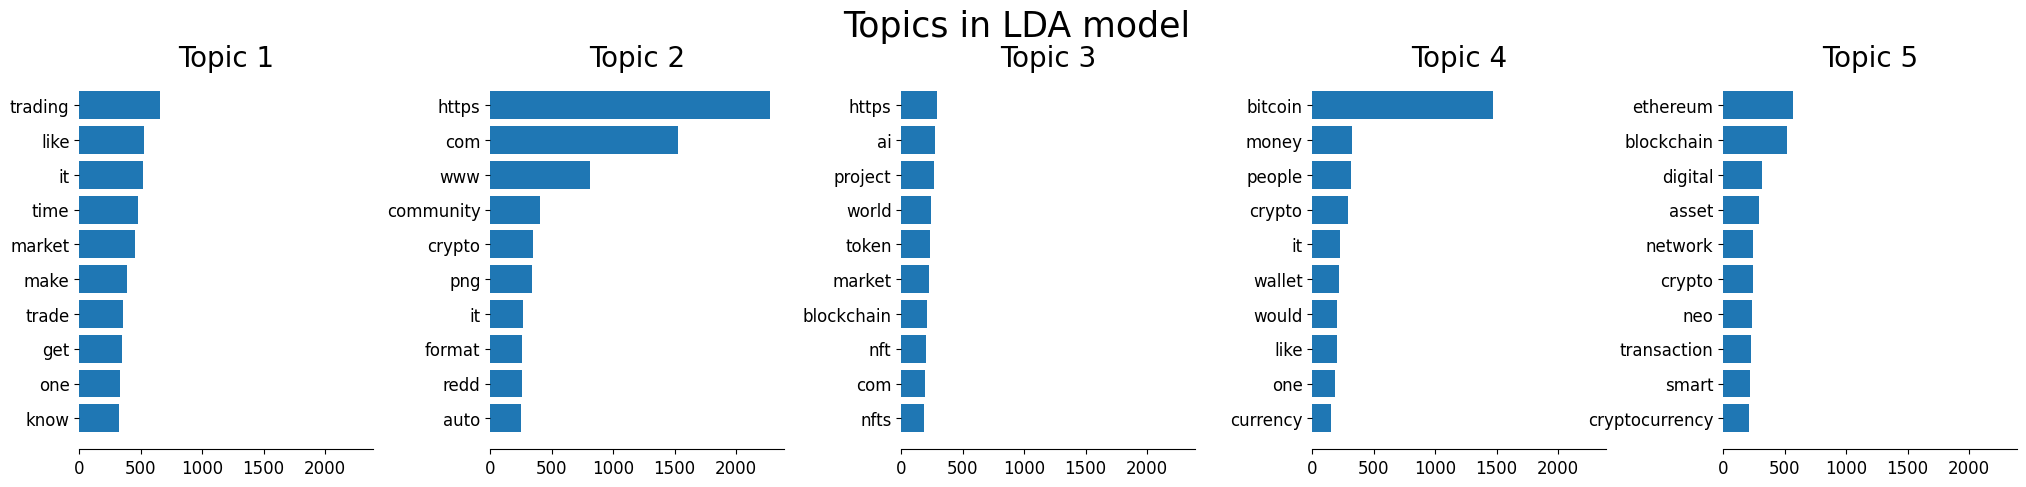

In [203]:
# build LDA model with tf
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit_transform(tf)
tf_feature_names = tf_vectorizer.get_feature_names_out()

plot_top_words(lda, tf_feature_names, n_top_words, "Topics in LDA model\n")

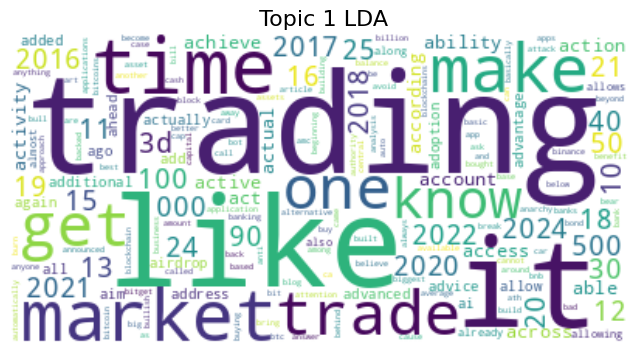

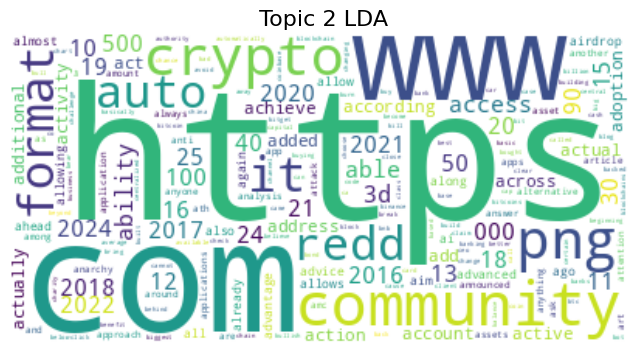

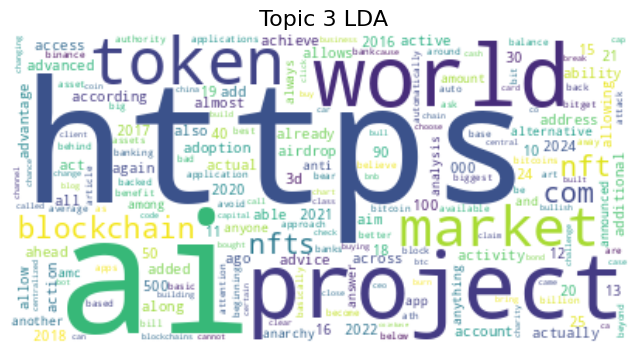

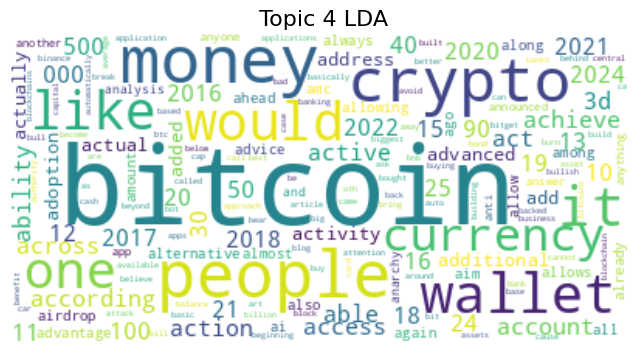

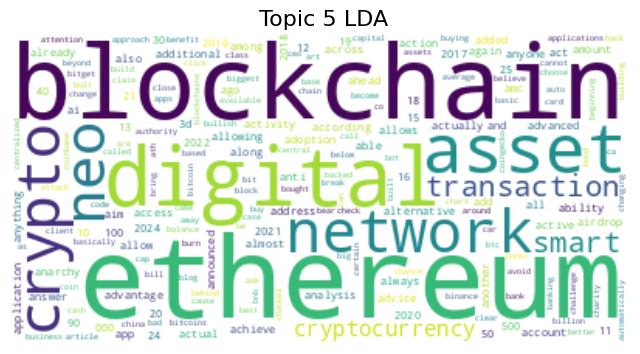

In [ ]:
# generate wordclouds for LDA
generate_wordclouds_with_corpus(lda, tf_feature_names, "LDA")

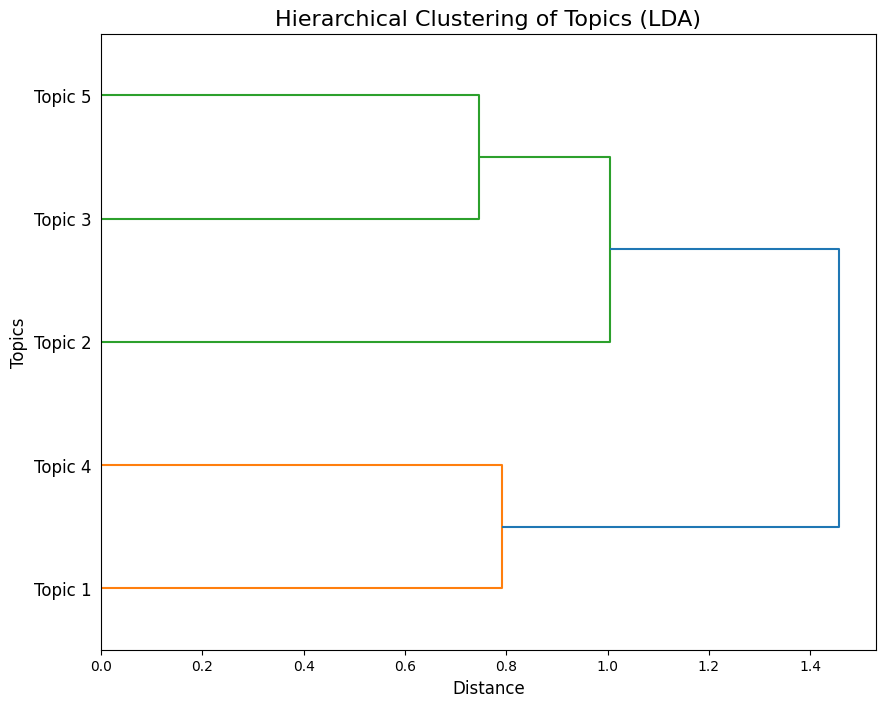

In [274]:
# plot hierarchical clustering for LDA
plot_topic_similarity_hierarchical_clustering(lda, "LDA")

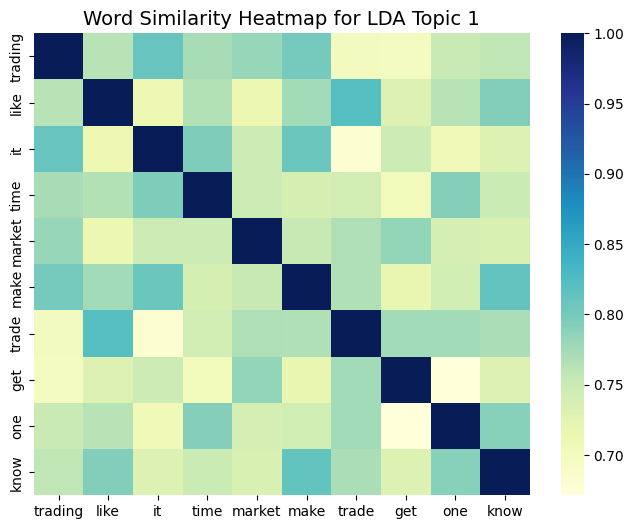

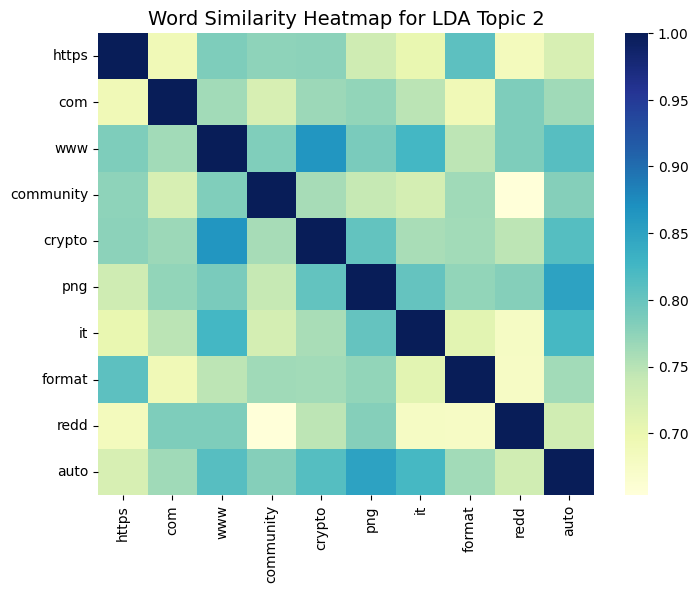

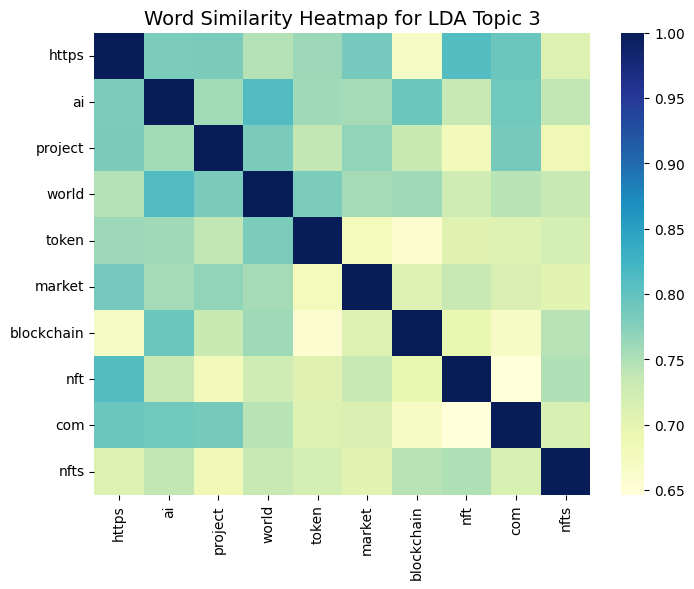

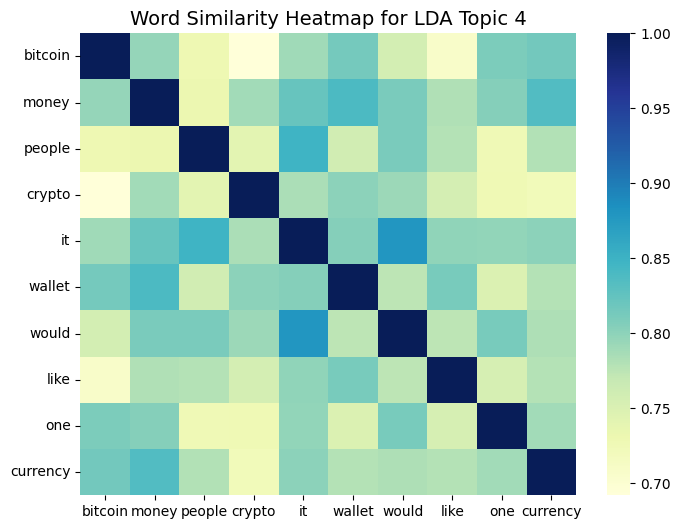

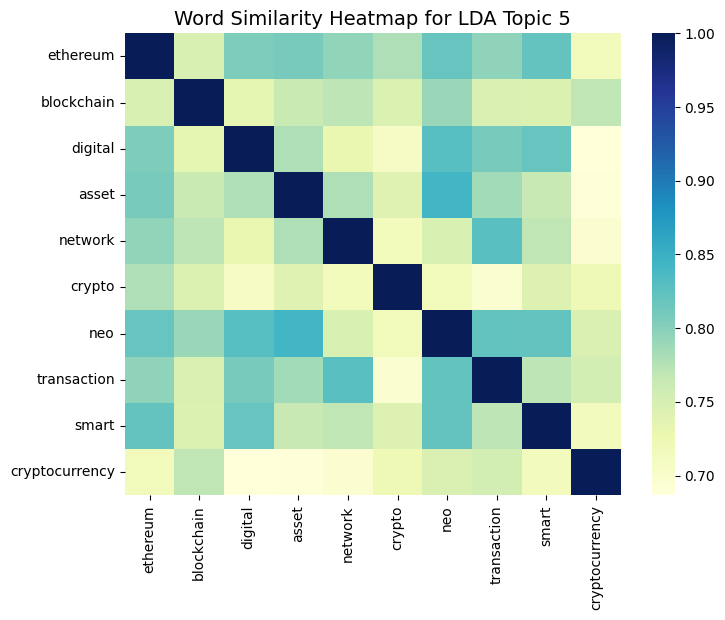

In [260]:
# plot word similarity heatmap per topic for LDA
plot_word_similarity_heatmap_per_topic(lda, tf_feature_names, "LDA")

#### NMF Model Training

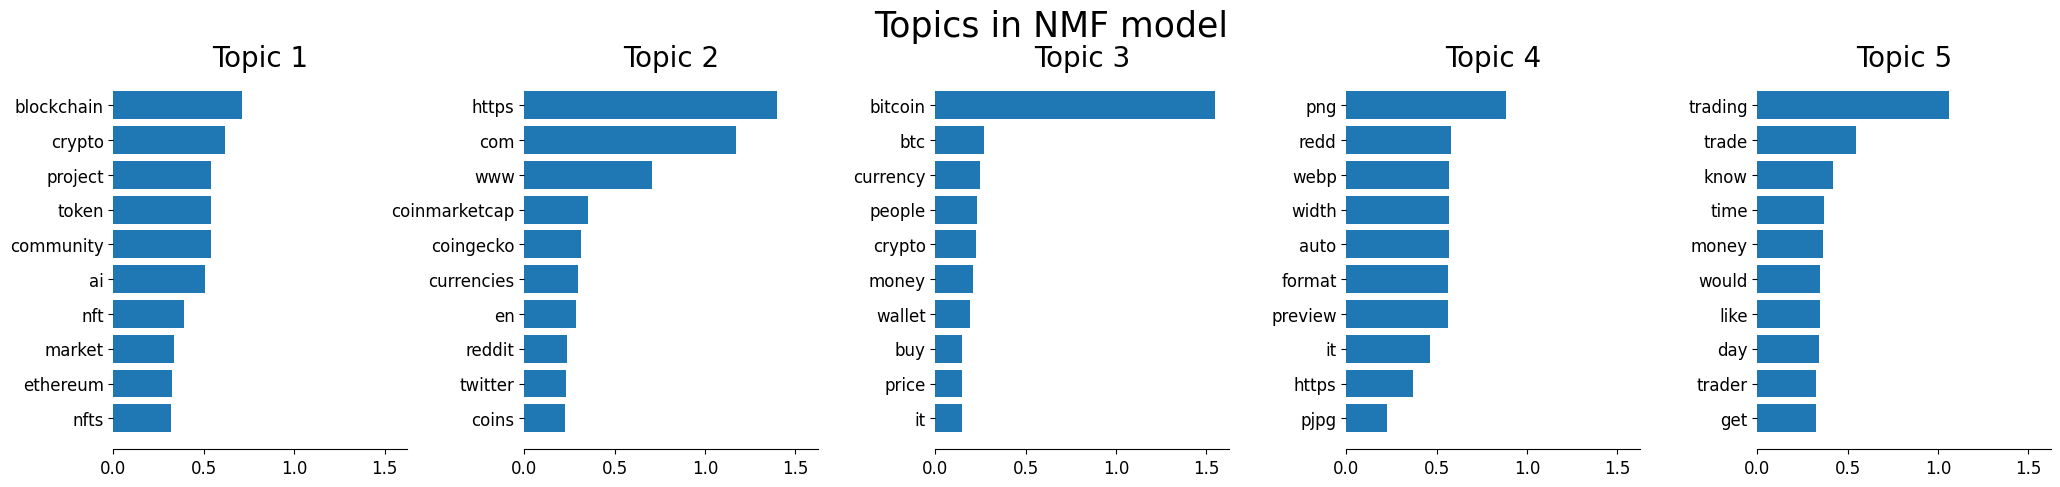

In [206]:
nmf = NMF(n_components=n_topics, random_state=42, beta_loss="frobenius").fit(tfidf)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

plot_top_words(nmf, tfidf_feature_names, n_top_words, "Topics in NMF model")

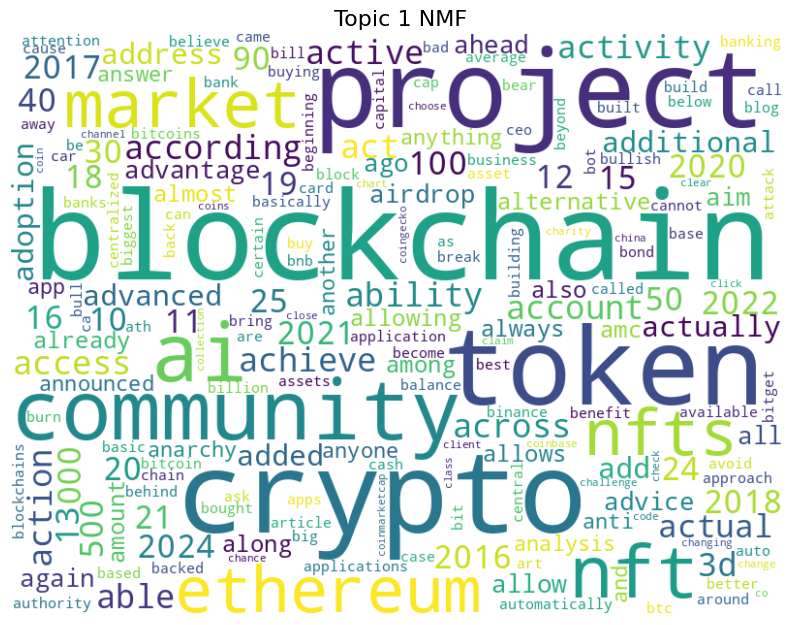

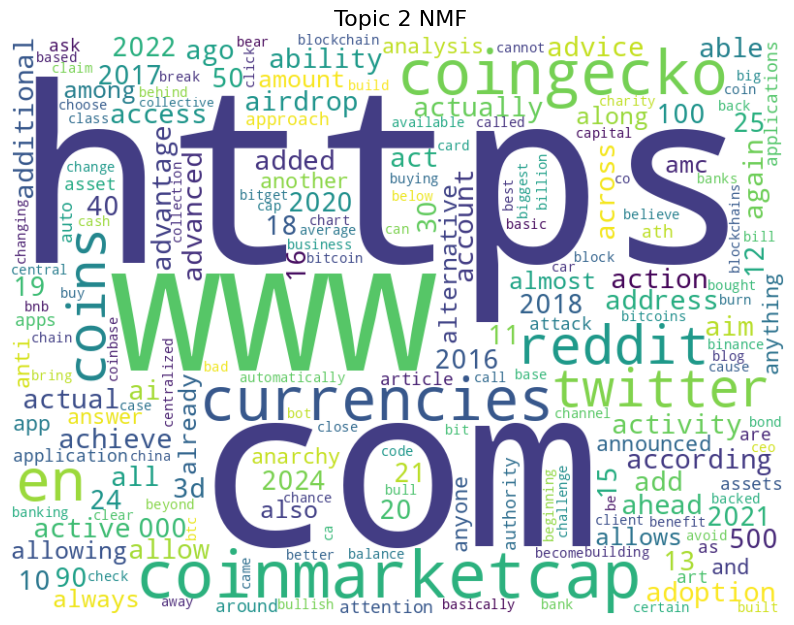

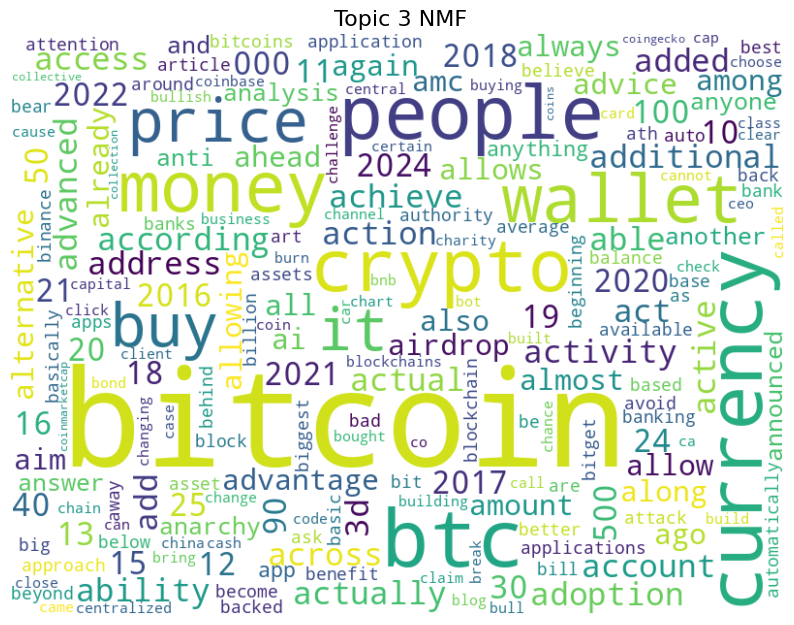

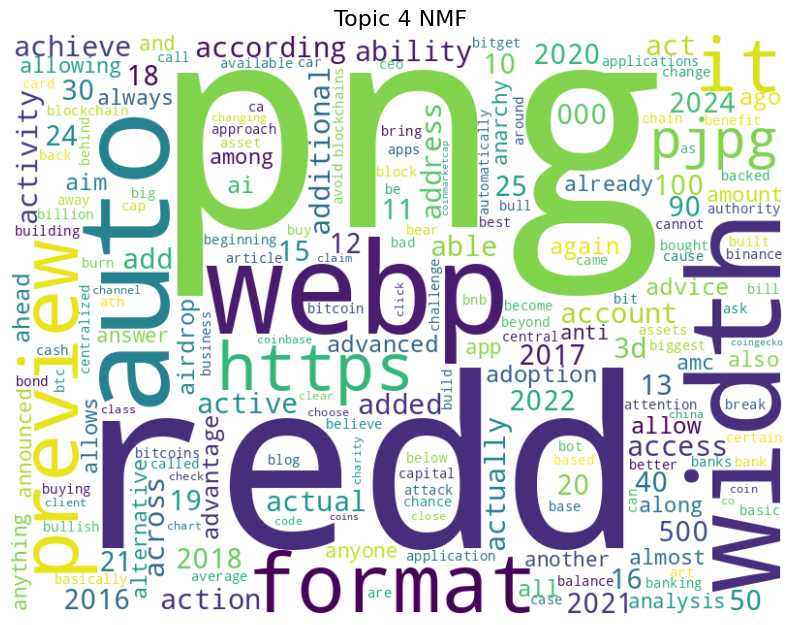

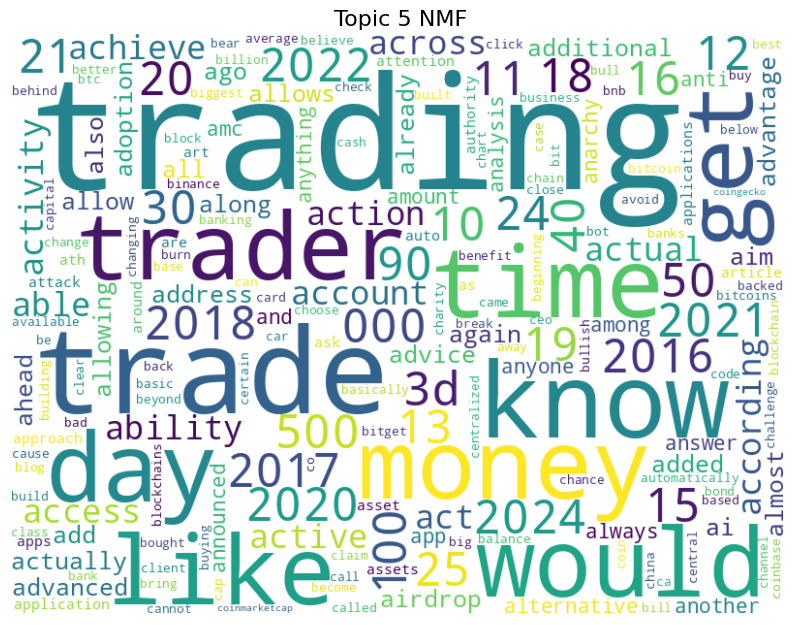

In [ ]:
# generate wordclouds for NMF
generate_wordclouds_with_corpus(nmf, tf_feature_names, "NMF")

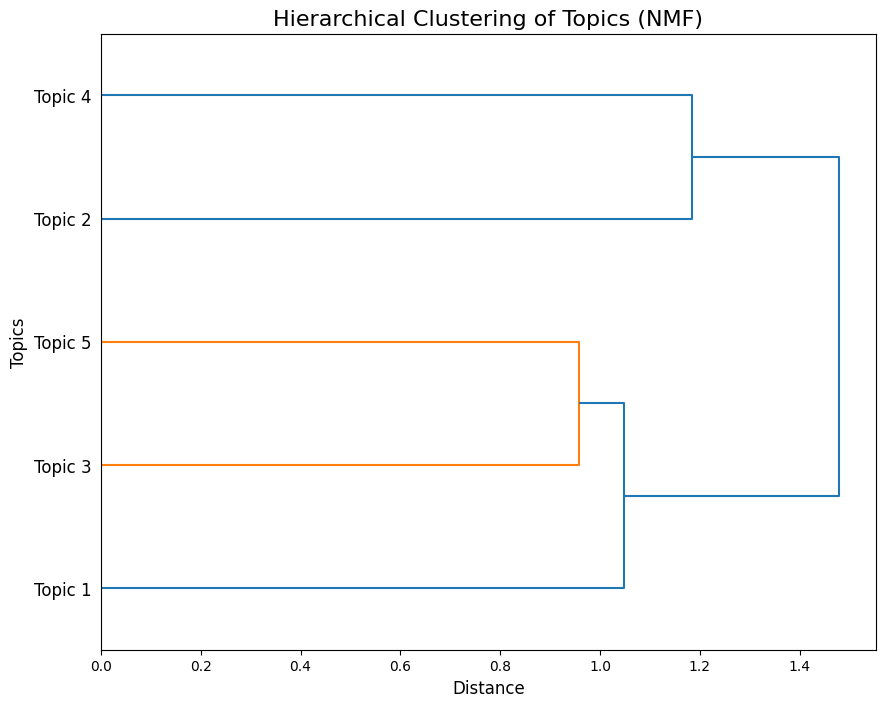

In [275]:
# plot hierarchical clustering for NMF
plot_topic_similarity_hierarchical_clustering(nmf, "NMF")

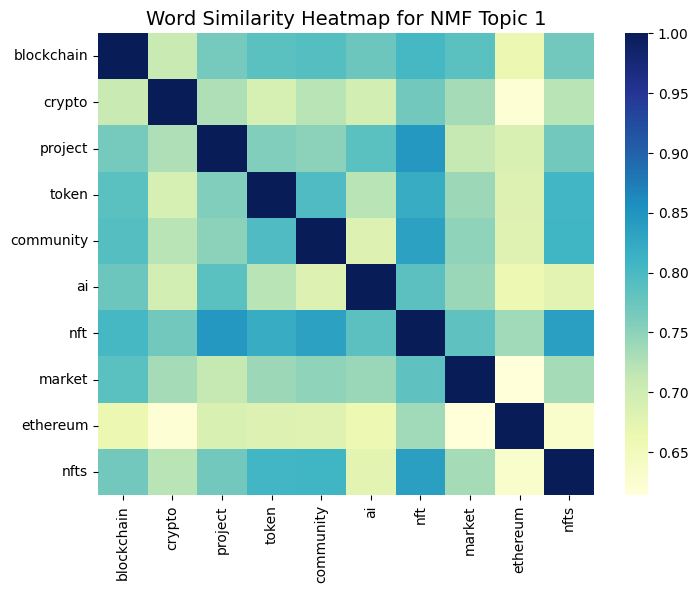

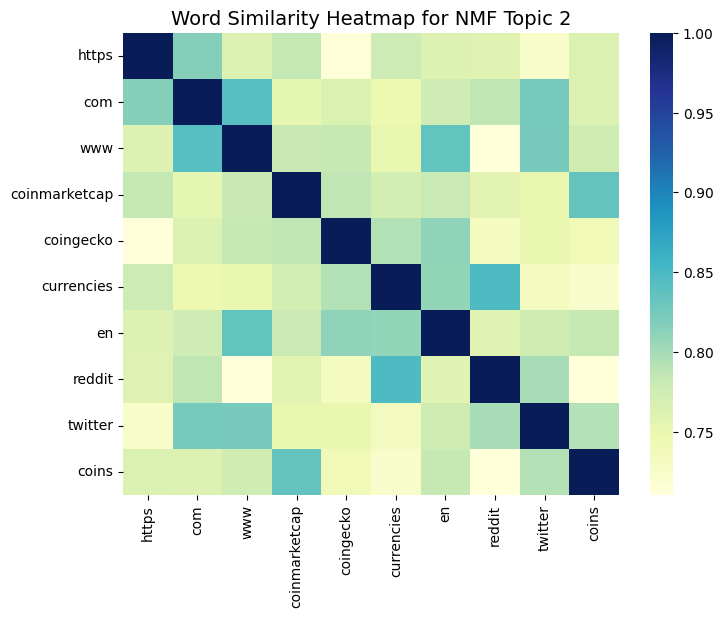

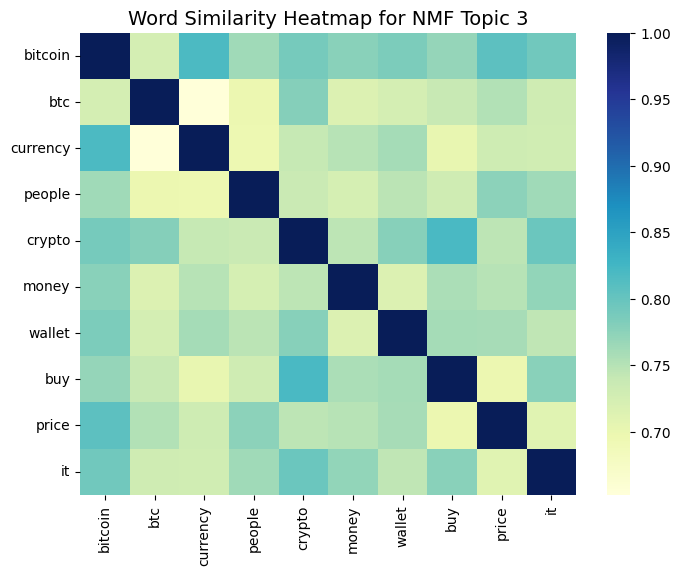

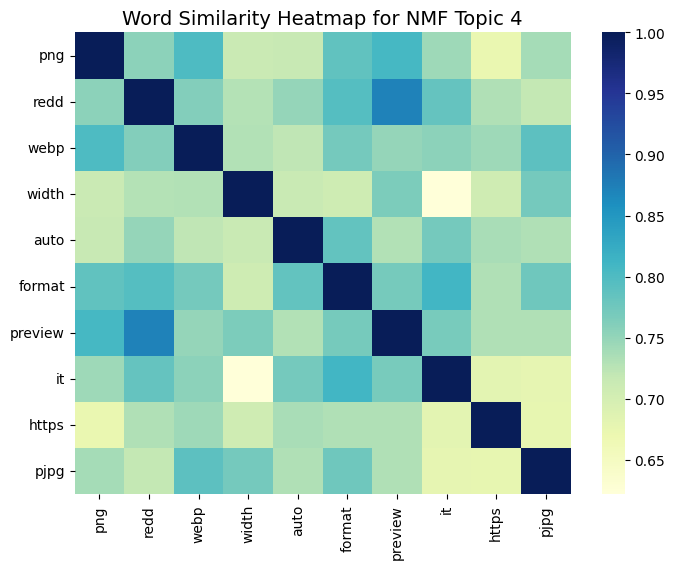

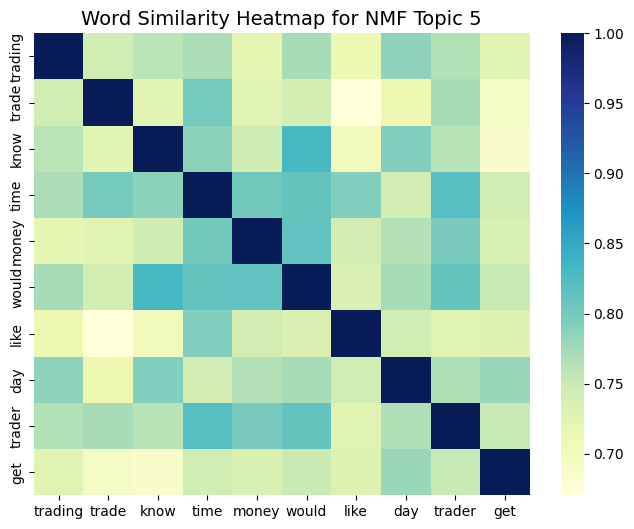

In [262]:
# plot word similarity heatmap per topic for NMF
plot_word_similarity_heatmap_per_topic(nmf, tf_feature_names, "NMF")

#### Analysis of LDA Model

In [205]:
# visualize the topics
pyLDAvis.enable_notebook()

LDAvis_prepared = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)

pyLDAvis.save_html(LDAvis_prepared, 'content_'+ str(n_topics) +'.html')

LDAvis_prepared

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.017173  0.000300       1        1  32.001094
3      0.008917 -0.010208       2        1  19.223451
2     -0.003402 -0.005030       3        1  19.168806
0      0.008778  0.006112       4        1  17.573830
1      0.002880  0.008826       5        1  12.032820, topic_info=           Term         Freq        Total Category  logprob  loglift
299     bitcoin  1446.000000  1446.000000  Default  30.0000  30.0000
173     trading   696.000000   696.000000  Default  29.0000  29.0000
324      crypto  1149.000000  1149.000000  Default  28.0000  28.0000
110      market   806.000000   806.000000  Default  27.0000  27.0000
13   blockchain   704.000000   704.000000  Default  26.0000  26.0000
..          ...          ...          ...      ...      ...      ...
313   community    47.097784   538.864035   Topic5  -6.1949  -0.3197
505         use    42.730899   405.267316   Topic5  -6.2922  -0.1321
809    ethereum    45.336390   610.468580   Topic5  -6.2331  -0.4826
606       first    42.049234   394.580947   Topic5  -6.3083  -0.1215
219        make    41.069215   486.231886   Topic5  -6.3319  -0.3539

[442 rows x 6 columns], token_table=       Topic      Freq     Term
term                           
10797      1  0.730662  academy
10797      2  0.040592  academy
10797      3  0.162369  academy
10797      4  0.081185  academy
10797      5  0.040592  academy
...      ...       ...      ...
2208       4  0.096576  zircuit
2208       5  0.096576  zircuit
2210       1  0.212331      zrc
2210       2  0.636994      zrc
8611       4  0.533130     zrvo

[947 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 3, 1, 2])